# Selección de variables con pyWinEA para presión arterial media (MAP)

Este notebook usa **pyWinEA** para seleccionar variables mediante **Algoritmos Genéticos** sobre el dataset del proyecto.

Para el entrenamiento y test se ha realizado un split de los datos del dataset `trainset` y `trainset_target`.

> Se ha utilizado cómo referencia para el uso de este algoritmo el github: https://github.com/FernandoGaGu/pywinEA


In [1]:
# %env SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True

In [2]:
# %pip install pyWinEA

In [3]:
import pywinEA
print("pyWinEA ok")

pyWinEA ok


c:\Users\Usuario\miniconda3\envs\tfm\Lib\site-packages\pywinEA\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


## 1. Cargar librerías e importar dataset

En esta sección se cargan tanto las librerías como el set de datos que se van a emplear a lo largo de este notebook.

In [1]:
import os
from pathlib import Path
import warnings
import ast
import math

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt


from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    make_scorer,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score
)

from pywinEA.algorithm import GA
from pywinEA.algorithm import NSGA2
from pywinEA.population import Population
from pywinEA.fitness import MonoObjectiveCV
from pywinEA.operators import TournamentSelection

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


c:\Users\Usuario\miniconda3\envs\tfm\Lib\site-packages\pywinEA\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


Carga del dataset 

In [57]:
dataset_path = Path("trainset.csv")
targetset_path = Path("trainset_target.csv")
print(f"Dataset encontrado: {dataset_path}")

if dataset_path.suffix.lower() == ".csv":
    df_set = pd.read_csv(dataset_path)
    df_target = pd.read_csv(targetset_path)
else:
    raise ValueError(f"Formato no soportado: {dataset_path.suffix}")

print(df_set.shape)
df_set.head()


Dataset encontrado: trainset.csv
(1919, 69)


,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,tamano_manguito_pa_4.0,tamano_manguito_pa_5.0,estado_elastografia_1,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL',raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [3]:
df_target

,hipertension
0,1
1,0
2,1
3,1
4,1
...,...
1914,1
1915,0
1916,0
1917,1


## 2. División train-test y categóricas-numéricas

En esta sección se divide el dataset que se ha cargado previamente en dos subsets: train y test.

El preprocesamiento ya fue realizado en otro de nuestros notebooks `missForest_imp_tfm`.

In [ ]:
# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    df_set,
    df_target,
    test_size=0.3,      # 30% para test
    random_state=42,    # reproducibilidad
    shuffle=True
)

# Ver tamaños
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1343, 69)
(576, 69)
(1343, 1)
(576, 1)


In [5]:
# Listas de variables numéricas y categóricas

# Variables categóricas:
# Se consideran categóricas todas aquellas binarias (0.0 y 1.0)
categorical_cols = [
    col for col in X_train.columns
    if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})
]

# Variables numéricas:
# Todas las demás variables
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

# Comprobación rápida
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numerical_cols)}")

# Mostrar ejemplos
print("\nPrimeras categóricas:")
print(categorical_cols[:10])

print("\nPrimeras numéricas:")
print(numerical_cols[:10])

Variables categóricas: 23
Variables numéricas: 46

Primeras categóricas:
['genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1', 'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1', 'convulsiones_1', 'caidas_1', 'fracturas_1']

Primeras numéricas:
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg']


> Como ya hicimos el preprocesamiento en el cuaderno `missForest_imp_tfm` no es necesario volver a realizar otro

## 3.1 Entrenamiento GA con varios modelos (pyWinEA)

En esta sección se procedio a generar un primer entrenamiento del GA (Algoritmo Genético) empleando hiperparámetros predeterminados.

Esta sección contiene:
1. Creación hiperparámetros para GA
2. Selección de 4 modelos para el GA con hiperparámetros pre-establecidos
3. Comparación y visualización de los resultados 

> Métricas empleadas para medir el modelo: `accuracy`, `f1`


In [ ]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0


def sensitivity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0


def gmean_score(y_true, y_pred):
    sensitivity = sensitivity_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

fitness_models = {
     "LogisticRegression": LogisticRegression(
         max_iter=1000,
         class_weight="balanced",
         solver="liblinear",
         random_state=RANDOM_STATE
     ),
    
     "SVC": SVC(
         kernel="rbf",
         class_weight="balanced",
         probability=True,
         random_state=RANDOM_STATE
     ),
    
     "RandomForest": RandomForestClassifier(
         max_depth=3,
         class_weight="balanced",
         random_state=RANDOM_STATE,
     ),
    
    # "GradientBoosting": GradientBoostingClassifier(
    #     learning_rate=0.1,
    #     max_depth=3,
    #     random_state=RANDOM_STATE
    # ),
    
    "DecisionTree_depth3": DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

# mediante esta línea se convierte gmean en el measure
scorer = "f1" # make_scorer(gmean_score) "accuracy"

POPULATION_SIZE = 200  # Cambiar a 300 si es en servidores
GENERATIONS = 80
ANNIHILATION = 0.10
ELITISM = 0.15
MUTATION_RATE = 0.05

Entrenamiento GA

In [10]:
ga_results = []
ga_models = {}

for model_name, fitness_model in fitness_models.items():
    print(f"\nEntrenando GA con fitness model: {model_name}")
    
    ga = GA(
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        cv=cv_strategy,
        fitness=fitness_model,
        score=scorer,
        annihilation=ANNIHILATION,
        elitism=ELITISM,
        mutation_rate=MUTATION_RATE,
        positive_class=1,
        id=f"GA_MAP_alta_{model_name}"
    )
    
    ga.set_features(X_train.columns.tolist())
    
    ga.fit(
        X_train.values,
        y_train.values.ravel()
    )
    
    selected_features_model = list(ga.best_features)
    evolution, score_name = ga.training_evolution()
    
    ga_models[model_name] = {
        "ga": ga,
        "selected_features": selected_features_model,
        "evolution": evolution,
        "score_name": score_name
    }
    
    ga_results.append({
        "fitness_model": model_name,
        "n_variables_originales": X_train.shape[1],
        "n_variables_seleccionadas": len(selected_features_model),
        "best_performance": ga.best_performance
    })

df_ga_results = pd.DataFrame(ga_results)
df_ga_results



Entrenando GA con fitness model: LogisticRegression


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [08:12<00:00,  6.16s/it]



Entrenando GA con fitness model: SVC


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [3:40:03<00:00, 165.04s/it]  



Entrenando GA con fitness model: RandomForest


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [2:45:04<00:00, 123.81s/it]  



Entrenando GA con fitness model: DecisionTree_depth3


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [10:26<00:00,  7.83s/it]


,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
0,LogisticRegression,69,31,{'f1': 0.6661082593487384}
1,SVC,69,50,{'f1': 0.6739459589201466}
2,RandomForest,69,52,{'f1': 0.6641454119288421}
3,DecisionTree_depth3,69,16,{'f1': 0.6660370782776374}


### Apartado Auxiliar: Guardado entre medias

Devido a las limitaciones de la CPU y al incremento progresivo de los tiempos de entrenamiento se realizó un guardado "checkpoint" para asegurar los resultados ya obtenidos de los modelos.

In [11]:
# df_ga_results = pd.DataFrame(ga_results)
# df_ga_results

# import pickle
# from pathlib import Path

# Path("checkpoints").mkdir(exist_ok=True)

# with open("checkpoints/ga_results_parcial.pkl", "wb") as f:
#     pickle.dump(ga_results, f)

# with open("checkpoints/ga_models_parcial.pkl", "wb") as f:
#     pickle.dump(ga_models, f)

# df_ga_results.to_csv("checkpoints/df_ga_results_parcial.csv", index=False)

# print("Guardado OK")
# df_ga_results

Comprobación de que podemos acceder:

In [12]:
# from pathlib import Path
# import pickle
# import joblib

# checkpoint_dir = Path("checkpoints")

# with open(checkpoint_dir / "ga_results_parcial.pkl", "rb") as f:
#     ga_results_checkpoint = pickle.load(f)

# with open(checkpoint_dir / "ga_models_parcial.pkl", "rb") as f:
#     ga_models_checkpoint = pickle.load(f)

# print("Modelos del checkpoint:", list(ga_models_checkpoint.keys()))
# print("Resultados del checkpoint:", len(ga_results_checkpoint))

In [13]:
# ga_models_all = ga_models_checkpoint.copy()
# ga_models_all.update(ga_models)
# ga_models = ga_models_all

# ga_results_all = ga_results_checkpoint.copy()
# ga_results_all.extend(ga_results)
# ga_results = ga_results_all

# df_ga_results = pd.DataFrame(ga_results)

# print("Modelos finales:", list(ga_models_all.keys()))
# display(df_ga_results)

Para guardar los resultados en caso de no poder hacer la ejecución de todas las celdas

In [14]:
# from pathlib import Path
# import pickle
# import joblib

# Comentar línea que no corresponda al "score" utilizado en el ga
# output_dir = Path("output_ga") / "accuracy_models" / "no_grid" # Cambiar a: "grid_before" / "grid_after"
# Para F1:
# # output_dir = Path("output_ga") / "f1_models" / "no_grid" # Cambiar a: "grid_before" / "grid_after"

# output_dir.mkdir(parents=True, exist_ok=True)

# with open(output_dir / "ga_models.pkl", "wb") as f:
#     pickle.dump(ga_models, f)

# with open(output_dir / "ga_results.pkl", "wb") as f:
#     pickle.dump(ga_results, f)

# df_ga_results.to_csv(output_dir / "df_ga_results.csv", index=False)
# df_ga_results.to_excel(output_dir / "df_ga_results.xlsx", index=False)

# joblib.dump(ga_models, output_dir / "ga_models.joblib")

# print("Guardado completo en:", output_dir.resolve())
# print("Archivos:")
# for file in output_dir.iterdir():
#     print(file.name, "-", file.stat().st_size, "bytes")

El siguiente código es para cargar los modelos y resultados en caso de haberse reiniciado el kernel.

Descomentar para utilizar

In [15]:
# Comentar línea que no corresponda al "score" utilizado en el ga
# results_dir = Path("output_ga", "accuracy_models" , "no_grid")  # Cambiar a: "grid_before" / "grid_after"
# #results_dir = Path("output_ga", "f1_models" , "no_grid")  # Cambiar a: "grid_before" / "grid_after"

# ga_models = joblib.load(results_dir / "ga_models.pkl")

# df_ga_grid_results = pd.read_csv(results_dir / "df_ga_results.csv")

# print(list(ga_models.keys()))

### Evaluar y comparar modelos

A continuación vamos a comprobar con un modelo simple si la selección de variables que ha realizado el `ga` obtiene mejores resultados.

Función para evaluar los modelos:

In [ ]:
def evaluar_modelo(nombre, modelo, X_train_eval, X_test_eval, y_train, y_test):
    modelo.fit(X_train_eval, y_train.values.ravel())
    
    y_pred = modelo.predict(X_test_eval)
    
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test_eval)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    return {
        "modelo": nombre,
        "n_variables": X_train_eval.shape[1],
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "sensibilidad": sensitivity_score(y_test, y_pred),
        "especificidad": specificity_score(y_test, y_pred),
        "g_mean": gmean_score(y_test, y_pred),
        "roc_auc": roc_auc
    }

In [ ]:
evaluation_results = []

for model_name, info in ga_models.items():
    selected_features_model = info["selected_features"]
    
    final_model = fitness_models[model_name]
    
    evaluation_results.append(
        evaluar_modelo(
            nombre=f"{model_name}_pyWinEA",
            modelo=final_model,
            X_train_eval=X_train[selected_features_model],
            X_test_eval=X_test[selected_features_model],
            y_train=y_train,
            y_test=y_test
        )
    )

df_evaluation = (
    pd.DataFrame(evaluation_results)
    .sort_values(["g_mean", "especificidad"], ascending=False)
)

df_evaluation


,modelo,n_variables,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,roc_auc
0,LogisticRegression_pyWinEA,31,0.663194,0.643382,0.663371,0.665399,0.661342,0.663367,0.701393
1,SVC_pyWinEA,50,0.628472,0.623239,0.632029,0.673004,0.591054,0.630699,0.697032
2,RandomForest_pyWinEA,52,0.612847,0.596745,0.614008,0.627376,0.600639,0.613862,0.673866
3,DecisionTree_depth3_pyWinEA,16,0.555556,0.628986,0.577084,0.825095,0.329073,0.521073,0.588248


Evaluación del número de generaciones más óptimo para cada modelo

In [18]:
generation_summary = []

for model_name, info in ga_models.items():
    evolution = info["evolution"]
    score_name = info["score_name"]
    
    best_score_key = f"best_{score_name}"
    best_features_key = "best_num_features"
    
    df_evol = pd.DataFrame({
        "generation": list(evolution[best_score_key].keys()),
        "best_g_mean": list(evolution[best_score_key].values()),
        "best_num_features": list(evolution[best_features_key].values())
    })
    
    df_evol["fitness_model"] = model_name
    
    best_generation = df_evol.loc[df_evol["best_g_mean"].idxmax(), "generation"]
    best_gmean = df_evol["best_g_mean"].max()
    
    df_evol["best_generation"] = best_generation
    df_evol["max_g_mean"] = best_gmean
    
    generation_summary.append(df_evol)

df_generation_evolution = pd.concat(generation_summary, ignore_index=True)

df_generation_evolution.head()

,generation,best_g_mean,best_num_features,fitness_model,best_generation,max_g_mean
0,0,0.634467,50,LogisticRegression,69,0.666108
1,1,0.639441,50,LogisticRegression,69,0.666108
2,2,0.639441,50,LogisticRegression,69,0.666108
3,3,0.645794,30,LogisticRegression,69,0.666108
4,4,0.645794,30,LogisticRegression,69,0.666108


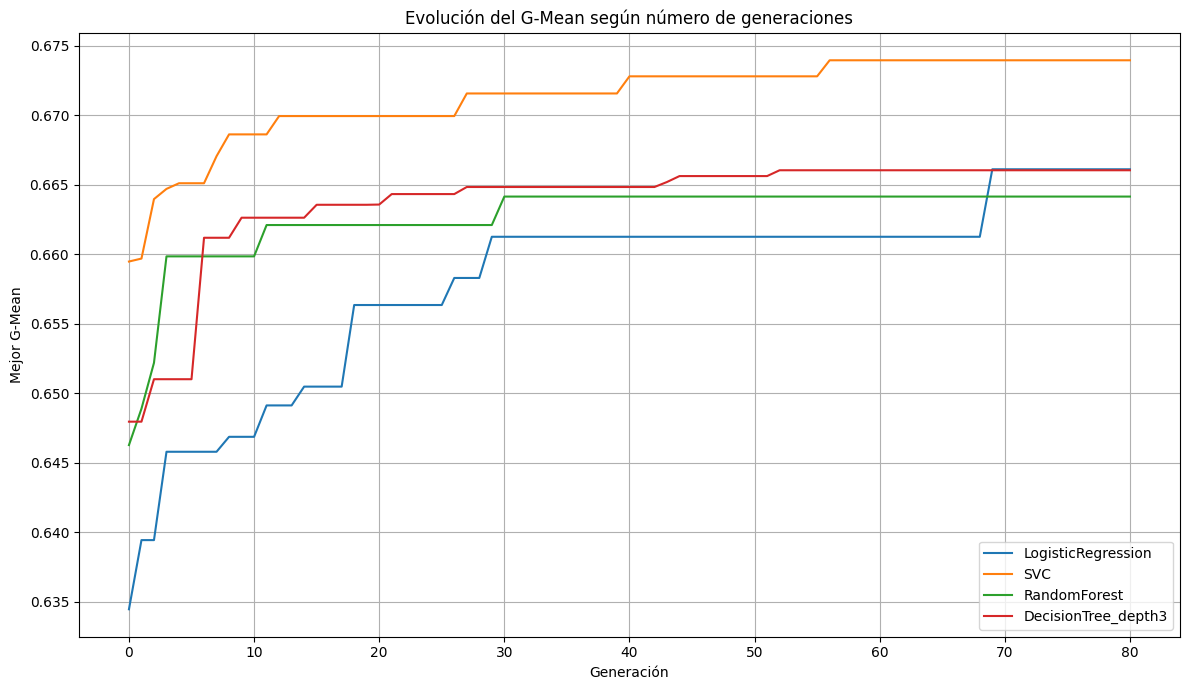

In [19]:
plt.figure(figsize=(12, 7))

for model_name in df_generation_evolution["fitness_model"].unique():
    df_temp = df_generation_evolution[
        df_generation_evolution["fitness_model"] == model_name
    ]
    
    plt.plot(
        df_temp["generation"],
        df_temp["best_g_mean"],
        label=model_name
    )

plt.title("Evolución del G-Mean según número de generaciones")
plt.xlabel("Generación")
plt.ylabel("Mejor G-Mean")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
df_optimal_generations = (
    df_generation_evolution
    .sort_values(["fitness_model", "best_g_mean"], ascending=[True, False])
    .groupby("fitness_model")
    .head(1)
    [["fitness_model", "generation", "best_g_mean", "best_num_features"]]
    .rename(columns={
        "generation": "generacion_optima",
        "best_g_mean": "mejor_g_mean",
        "best_num_features": "n_variables_en_generacion_optima"
    })
    .sort_values("mejor_g_mean", ascending=False)
)

df_optimal_generations

,fitness_model,generacion_optima,mejor_g_mean,n_variables_en_generacion_optima
137,SVC,56,0.673946,50
69,LogisticRegression,69,0.666108,31
295,DecisionTree_depth3,52,0.666037,16
192,RandomForest,30,0.664145,52


### Guardar

In [23]:

# Guardado de resultados 

# Comentar línea que no corresponda al "score" utilizado en el ga
# OUTPUT_DIR = Path("output_ga", "accuracy_models" , "no_grid")  
OUTPUT_DIR = Path("output_ga", "f1_models" , "no_grid")  
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(ga_models, OUTPUT_DIR / "ga_models.pkl")

df_ga_results.to_csv(
    OUTPUT_DIR / "ga_results.csv",
    index=False
)

df_evaluation.to_csv(
    OUTPUT_DIR / "evaluation_models.csv",
    index=False
)

df_generation_evolution.to_csv(
    OUTPUT_DIR / "evolution_generations_by_fitness.csv",
    index=False
)

df_optimal_generations.to_csv(
    OUTPUT_DIR / "optimal_generations_by_fitness.csv",
    index=False
)

for model_name, info in ga_models.items():
    pd.Series(
        info["selected_features"],
        name="variable"
    ).to_csv(
        OUTPUT_DIR / f"variables_seleccionadas_{model_name}.csv",
        index=False
    )

print("Resultados guardados correctamente.")

Resultados guardados correctamente.


### Visualizar importancia variables

Visualiza los pesos asignados por los modelos a las variables en los casos en los q lo haga.

In [ ]:
importancias_modelos = {}

for model_name, info in ga_models.items():
    selected_features_model = info["selected_features"]
    modelo_final = fitness_models[model_name]

    modelo_final.fit(X_train[selected_features_model], y_train.values.ravel())

    if hasattr(modelo_final, "feature_importances_"):
        valores = modelo_final.feature_importances_
    elif hasattr(modelo_final, "coef_"):
        valores = abs(modelo_final.coef_).ravel()
    else:
        print(f"{model_name}: sin importancias directas")
        continue

    importancias_modelos[model_name] = (
        pd.DataFrame({
            "variable": selected_features_model,
            "importancia": valores
        })
        .query("importancia > 0")
        .sort_values("importancia", ascending=False)
    )

for model_name, importancias in importancias_modelos.items():
    print(f"\n=== {model_name} ===")
    display(importancias.head(15))


SVC: sin importancias directas

=== LogisticRegression ===


,variable,importancia
16,raza_etnia_3.0,0.669451
23,edad_an,0.562477
25,peso_kg,0.523573
15,medicacion_osteoporosis_1,0.371300
18,trigliceridos_mmol_l,0.361232
28,pulso,0.334811
7,hemoglobina_g_dl,0.286348
9,caidas_1,0.279412
0,hdl_mmol_l,0.276309
11,intentos_totales_elasto,0.222518



=== RandomForest ===


,variable,importancia
0,peso_kg,0.110650
18,edad_an,0.110609
25,albumina_orina_mg_l,0.090658
30,imc,0.067641
14,trigliceridos_mmol_l,0.065667
11,ratio_albumina_creatinina,0.061026
26,hemoglobina_g_dl,0.058404
23,pulso,0.044773
19,proteina_c_reactiva_mg_l,0.031273
9,ldl_martin_mmol_l,0.028328



=== DecisionTree_depth3 ===


,variable,importancia
11,imc,0.427531
12,ratio_albumina_creatinina,0.268602
3,genero_1,0.125185
0,cadmio_sangre_nmol_l,0.122014
7,conc_hemoglobina_media,0.056668


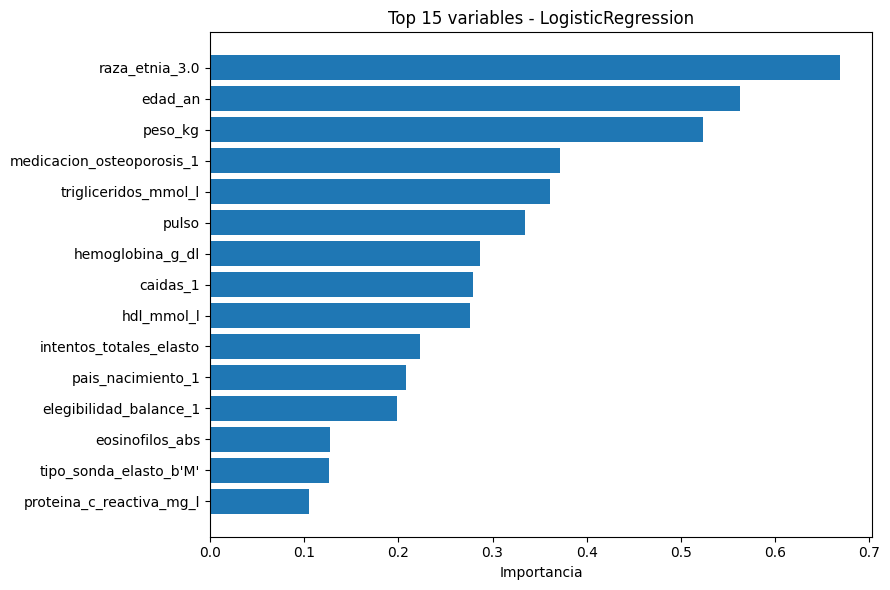

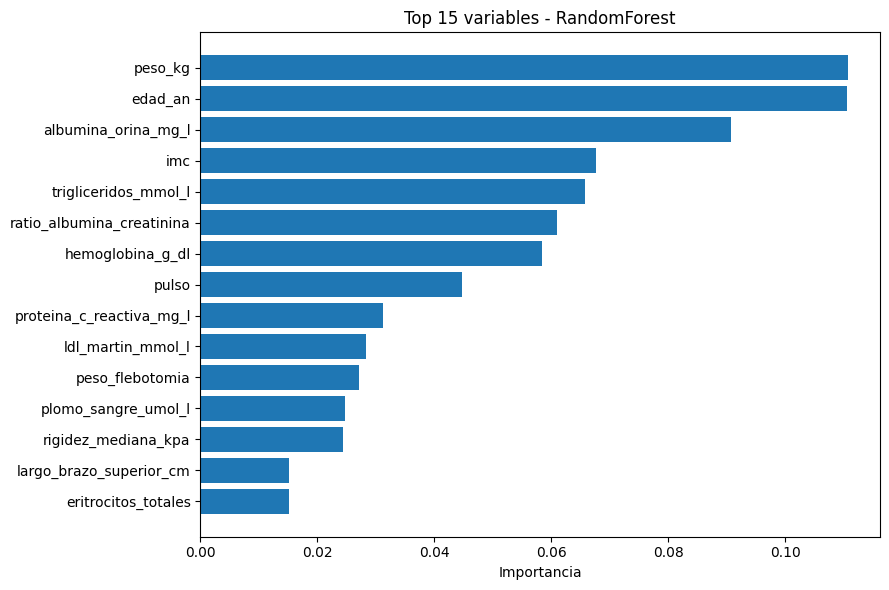

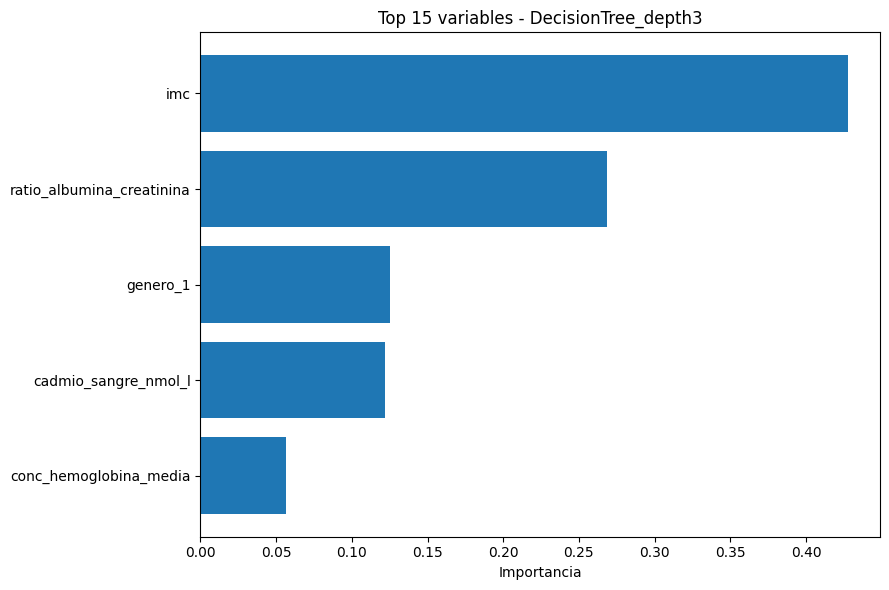

In [ ]:
top_n = 15

for model_name, importancias in importancias_modelos.items():
    top_importancias = importancias.head(top_n).sort_values("importancia")

    plt.figure(figsize=(9, 6))
    plt.barh(top_importancias["variable"], top_importancias["importancia"])
    plt.title(f"Top {top_n} variables - {model_name}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()


## 3.2 Aplicar Grid a modelos ya entrenados

`GridSearchCV` no “modifica” el modelo ya entrenado directamente. Usa su configuración como base, prueba hiperparámetros y reentrena el mejor modelo con las variables seleccionadas por pyWinEA.

En esta sección se va a comparar este ajuste posterior al entrenamiento con el resultado original.

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.metrics import classification_report

GRID_SCORING = "f1" # Cambiar por: "accuracy"

param_grids = {
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },

    "SVC": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1],
        "kernel": ["rbf"]
    },

    "RandomForest": {
        "n_estimators": [100, 300, 500],
        "max_depth": [3, 4, 5, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "GradientBoosting": {
        "n_estimators": [100, 150, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 4],
        "subsample": [0.8, 1.0]
    },

    "DecisionTree_depth3": {
        "max_depth": [3, 4],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    }
}

In [ ]:
print("Modelos disponibles en ga_models:")
print(list(ga_models.keys()))

print("\nModelos disponibles en param_grids:")
print(list(param_grids.keys()))

grid_models = {}
grid_results = []

for model_name, info in ga_models.items():

    print(f"\n{'='*60}")
    print(f"Aplicando GridSearch a: {model_name}")
    print(f"{'='*60}")

    if model_name not in param_grids:
        print(f"⚠️ No existe param_grid para {model_name}")
        continue

    try:

        selected_features_model = info["selected_features"]

        X_train_grid = X_train[selected_features_model]
        X_test_grid = X_test[selected_features_model]

        base_model = clone(fitness_models[model_name])

        grid = GridSearchCV(
            estimator=base_model,
            param_grid=param_grids[model_name],
            scoring=GRID_SCORING,
            cv=cv_strategy,
            n_jobs=-1,
            verbose=1,
            refit=True
        )

        grid.fit(
            X_train_grid,
            y_train.values.ravel()
        )

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_grid)

        if hasattr(best_model, "predict_proba"):
            y_proba = best_model.predict_proba(X_test_grid)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        else:
            roc_auc = np.nan

        resultado = {
            "modelo": model_name,
            "n_variables": len(selected_features_model),
            "grid_scoring": GRID_SCORING,
            "best_cv_score": grid.best_score_,
            "accuracy_test": accuracy_score(y_test, y_pred),
            "f1_test": f1_score(y_test, y_pred),
            "balanced_accuracy_test": balanced_accuracy_score(y_test, y_pred),
            "sensibilidad_test": sensitivity_score(y_test, y_pred),
            "especificidad_test": specificity_score(y_test, y_pred),
            "g_mean_test": gmean_score(y_test, y_pred),
            "roc_auc_test": roc_auc,
            "best_params": str(grid.best_params_)
        }

        grid_results.append(resultado)

        grid_models[model_name] = {
            "best_model": best_model,
            "best_params": grid.best_params_,
            "best_cv_score": grid.best_score_,
            "selected_features": selected_features_model,
            "grid_object": grid
        }

        print("✓ Finalizado correctamente")

    except Exception as e:

        print(f"✗ Error en {model_name}")
        print(e)

        continue


df_grid_results = pd.DataFrame(grid_results)

print("\nColumnas generadas:")
print(df_grid_results.columns.tolist())

print("\nNúmero de modelos optimizados:")
print(len(df_grid_results))

if not df_grid_results.empty:

    if (
        "g_mean_test" in df_grid_results.columns
        and
        "especificidad_test" in df_grid_results.columns
    ):
        df_grid_results = df_grid_results.sort_values(
            ["g_mean_test", "especificidad_test"],
            ascending=False
        )

    elif "best_cv_score" in df_grid_results.columns:
        df_grid_results = df_grid_results.sort_values(
            "best_cv_score",
            ascending=False
        )

df_grid_results

Modelos disponibles en ga_models:
['LogisticRegression', 'SVC', 'RandomForest', 'DecisionTree_depth3']

Modelos disponibles en param_grids:
['LogisticRegression', 'SVC', 'RandomForest', 'GradientBoosting', 'DecisionTree_depth3']

Aplicando GridSearch a: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✓ Finalizado correctamente

Aplicando GridSearch a: SVC
Fitting 5 folds for each of 9 candidates, totalling 45 fits
✓ Finalizado correctamente

Aplicando GridSearch a: RandomForest
Fitting 5 folds for each of 108 candidates, totalling 540 fits
✓ Finalizado correctamente

Aplicando GridSearch a: DecisionTree_depth3
Fitting 5 folds for each of 36 candidates, totalling 180 fits
✓ Finalizado correctamente

Columnas generadas:
['modelo', 'n_variables', 'grid_scoring', 'best_cv_score', 'accuracy_test', 'f1_test', 'balanced_accuracy_test', 'sensibilidad_test', 'especificidad_test', 'g_mean_test', 'roc_auc_test', 'best_params']

Número de modelos optimizados:
4


,modelo,n_variables,grid_scoring,best_cv_score,accuracy_test,f1_test,balanced_accuracy_test,sensibilidad_test,especificidad_test,g_mean_test,roc_auc_test,best_params
0,LogisticRegression,31,f1,0.666108,0.663194,0.643382,0.663371,0.665399,0.661342,0.663367,0.701393,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}"
1,SVC,50,f1,0.673946,0.628472,0.623239,0.632029,0.673004,0.591054,0.630699,0.697032,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
2,RandomForest,52,f1,0.665659,0.611111,0.595668,0.612410,0.627376,0.597444,0.612227,0.673150,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s..."
3,DecisionTree_depth3,16,f1,0.666037,0.555556,0.628986,0.577084,0.825095,0.329073,0.521073,0.588248,"{'criterion': 'gini', 'max_depth': 3, 'min_sam..."


Guardar los modelos obtenidos:

In [28]:
# GRID_OUTPUT_DIR = Path("output_ga", "accuracy_models", "grid_after")
# Para F1:
GRID_OUTPUT_DIR = Path("output_ga", "f1_models", "grid_after")
GRID_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    grid_models,
    GRID_OUTPUT_DIR / "grid_models_optimized.pkl"
)

df_grid_results.to_csv(
    GRID_OUTPUT_DIR / "grid_results.csv",
    index=False
)

df_grid_results.to_excel(
    GRID_OUTPUT_DIR / "grid_results.xlsx",
    index=False
)

print("Modelos optimizados guardados en:", GRID_OUTPUT_DIR.resolve())

Modelos optimizados guardados en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_ga\f1_models\grid_after


### Comparación entre original y post-Grid

In [ ]:
COMPARISON_SCORING = "f1" # Para cambiar: "accuracy"

comparison_results = []

for model_name in grid_models.keys():

    print(f"Comparando modelo: {model_name}")

    selected_features_model = grid_models[model_name]["selected_features"]

    original_model = clone(fitness_models[model_name])
    original_model.fit(
        X_train[selected_features_model],
        y_train.values.ravel()
    )

    grid_model = grid_models[model_name]["best_model"]

    pred_original = original_model.predict(X_test[selected_features_model])
    pred_grid = grid_model.predict(X_test[selected_features_model])

    comparison_results.append({
        "modelo": model_name,
        "version": "Original",
        "n_variables": len(selected_features_model),
        "accuracy": accuracy_score(y_test, pred_original),
        "f1": f1_score(y_test, pred_original)
    })

    comparison_results.append({
        "modelo": model_name,
        "version": "GridSearch",
        "n_variables": len(selected_features_model),
        "accuracy": accuracy_score(y_test, pred_grid),
        "f1": f1_score(y_test, pred_grid)
    })

df_comparison = pd.DataFrame(comparison_results)

df_comparison = df_comparison.sort_values(
    [COMPARISON_SCORING, "modelo"],
    ascending=[False, True]
)

df_comparison

Comparando modelo: LogisticRegression
Comparando modelo: SVC
Comparando modelo: RandomForest
Comparando modelo: DecisionTree_depth3


,modelo,version,n_variables,accuracy,f1
0,LogisticRegression,Original,31,0.663194,0.643382
1,LogisticRegression,GridSearch,31,0.663194,0.643382
6,DecisionTree_depth3,Original,16,0.555556,0.628986
7,DecisionTree_depth3,GridSearch,16,0.555556,0.628986
2,SVC,Original,50,0.628472,0.623239
3,SVC,GridSearch,50,0.628472,0.623239
4,RandomForest,Original,52,0.612847,0.596745
5,RandomForest,GridSearch,52,0.611111,0.595668


Como se puede apreciar la diferencia es prácticamente inexistente. Por lo tanto para comparar en el siguiente apartado con el GridSearch realizado a los modelos y previo al entrenamiento se realizarán comparaciones solamente con los modelos originales.

## 4. Aplicar GridSearch antes del entrenamiento

En este caso se realizó un GridSearch previo al entrenamiento para seleccionar la mejor combinación de hiperparámetros para cada modelo.

In [30]:
GRID_METRIC = "f1" #Para cambiar: "accuracy"

param_grids_previo = {
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l1", "l2"]
    },

    "SVC": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1]
    },

    "RandomForest": {
        "n_estimators": [100, 300],
        "max_depth": [3, 4, 5, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "DecisionTree_depth3": {
        "max_depth": [3, 4],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    }
}

Función para ejecutar GridSearch

In [31]:
def ejecutar_gridsearch_previo(model_name, model):
    
    print(f"GridSearch previo | Modelo: {model_name} | Métrica: {GRID_SCORING}")
    
    grid = GridSearchCV(
        estimator=clone(model),
        param_grid=param_grids_previo[model_name],
        scoring=GRID_SCORING,
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    
    grid.fit(
        X_train,
        y_train.values.ravel()
    )
    
    return grid

In [ ]:
before_grid_models = {}
before_grid_results = []

for model_name, model in fitness_models.items():
    
    grid = ejecutar_gridsearch_previo(
        model_name=model_name,
        model=model
    )
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    before_grid_models[model_name] = best_model
    
    before_grid_results.append({
        "modelo": model_name,
        "grid_scoring": GRID_SCORING,
        "best_cv_score": grid.best_score_,
        "accuracy_test": accuracy_score(y_test, y_pred),
        "f1_test": f1_score(y_test, y_pred),
        "best_params": grid.best_params_
    })

df_before_grid = pd.DataFrame(before_grid_results)

df_before_grid = df_before_grid.sort_values(
    "accuracy_test",
    ascending=False
)

df_before_grid

GridSearch previo | Modelo: LogisticRegression | Métrica: f1
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearch previo | Modelo: SVC | Métrica: f1
Fitting 5 folds for each of 9 candidates, totalling 45 fits
GridSearch previo | Modelo: RandomForest | Métrica: f1
Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearch previo | Modelo: DecisionTree_depth3 | Métrica: f1
Fitting 5 folds for each of 36 candidates, totalling 180 fits


,modelo,grid_scoring,best_cv_score,accuracy_test,f1_test,best_params
0,LogisticRegression,f1,0.640703,0.651042,0.622889,"{'C': 0.1, 'penalty': 'l1'}"
2,RandomForest,f1,0.641242,0.630208,0.598870,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s..."
1,SVC,f1,0.661790,0.616319,0.632280,"{'C': 0.1, 'gamma': 'scale'}"
3,DecisionTree_depth3,f1,0.596987,0.602431,0.656672,"{'criterion': 'gini', 'max_depth': 3, 'min_sam..."


> Guardar resultados previos al entrenamiento

In [33]:
# GRID_OUTPUT_DIR = Path("output_ga", "accuracy_models", "grid_before", "no_ga")
# Para F1:
GRID_OUTPUT_DIR = Path("output_ga", "f1_models", "grid_before", "no_ga")
GRID_OUTPUT_DIR.mkdir(
    parents=True, 
    exist_ok=True
    )

joblib.dump(
    before_grid_models,
    GRID_OUTPUT_DIR / "before_grid_models.pkl"
)

df_before_grid.to_csv(
    GRID_OUTPUT_DIR / "before_grid_results.csv",
    index=False
)

df_before_grid.to_excel(
    GRID_OUTPUT_DIR / "before_grid_results.xlsx",
    index=False
)

print("GridSearch previo con accuracy guardado correctamente.")
print("Ruta:", GRID_OUTPUT_DIR.resolve())

GridSearch previo con accuracy guardado correctamente.
Ruta: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_ga\f1_models\grid_before\no_ga


Ahora se va a proceder con el entrenamiento cambiando `fitness_models` por los modelos optimizados `before_grid_models`

In [34]:
# Entrenamiento GA
ga_grid_results = []
ga_grid_models = {}

for model_name, fitness_model in before_grid_models.items():
    print(f"\nEntrenando GA con fitness model: {model_name}")
    
    ga = GA(
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        cv=cv_strategy,
        fitness=fitness_model,
        score=scorer,
        annihilation=ANNIHILATION,
        elitism=ELITISM,
        mutation_rate=MUTATION_RATE,
        positive_class=1,
        id=f"GA_MAP_alta_{model_name}"
    )
    
    ga.set_features(X_train.columns.tolist())
    
    ga.fit(
        X_train.values,
        y_train.values.ravel()
    )
    
    selected_features_model = list(ga.best_features)
    evolution, score_name = ga.training_evolution()
    
    ga_grid_models[model_name] = {
        "ga": ga,
        "selected_features": selected_features_model,
        "evolution": evolution,
        "score_name": score_name
    }
    
    ga_grid_results.append({
        "fitness_model": model_name,
        "n_variables_originales": X_train.shape[1],
        "n_variables_seleccionadas": len(selected_features_model),
        "best_performance": ga.best_performance
    })

df_ga_grid_results = pd.DataFrame(ga_grid_results)
df_ga_grid_results



Entrenando GA con fitness model: LogisticRegression


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [06:59<00:00,  5.24s/it]



Entrenando GA con fitness model: SVC


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [4:00:25<00:00, 180.32s/it]  



Entrenando GA con fitness model: RandomForest


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [10:51:08<00:00, 488.36s/it] 



Entrenando GA con fitness model: DecisionTree_depth3


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [06:41<00:00,  5.02s/it]


,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
0,LogisticRegression,69,24,{'f1': 0.6676584613617874}
1,SVC,69,26,{'f1': 0.6833698308697276}
2,RandomForest,69,40,{'f1': 0.6634513993888994}
3,DecisionTree_depth3,69,12,{'f1': 0.6660370782776374}


In [ ]:
# from pathlib import Path
# import joblib
# import pandas as pd

# OUTPUT_DIR = Path("output_ga", "accuracy_models", "grid_before")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# model_name = "DecisionTree_depth3"
# fitness_model = before_grid_models[model_name]

# print(f"\nEntrenando GA restante con fitness model: {model_name}")

# ga = GA(
#     population_size=POPULATION_SIZE,
#     generations=GENERATIONS,
#     cv=cv_strategy,
#     fitness=fitness_model,
#     score=scorer,
#     annihilation=ANNIHILATION,
#     elitism=ELITISM,
#     mutation_rate=MUTATION_RATE,
#     positive_class=1,
#     id=f"GA_MAP_alta_{model_name}"
# )

# ga.set_features(X_train.columns.tolist())

# ga.fit(
#     X_train.values,
#     y_train.values.ravel()
# )

# selected_features_model = list(ga.best_features)
# evolution, score_name = ga.training_evolution()

# ga_grid_models[model_name] = {
#     "ga": ga,
#     "selected_features": selected_features_model,
#     "evolution": evolution,
#     "score_name": score_name
# }

# nuevo_resultado = {
#     "fitness_model": model_name,
#     "n_variables_originales": X_train.shape[1],
#     "n_variables_seleccionadas": len(selected_features_model),
#     "best_performance": ga.best_performance
# }

# ga_grid_results.append(nuevo_resultado)

# df_ga_grid_results = pd.DataFrame(ga_grid_results)

# joblib.dump(
#     ga_grid_models,
#     OUTPUT_DIR / "ga_grid_models.pkl"
# )

# joblib.dump(
#     ga_grid_results,
#     OUTPUT_DIR / "ga_grid_results.pkl"
# )

# df_ga_grid_results.to_csv(
#     OUTPUT_DIR / "df_ga_grid_results.csv",
#     index=False
# )

# df_ga_grid_results.to_excel(
#     OUTPUT_DIR / "df_ga_grid_results.xlsx",
#     index=False
# )

# print("Entrenamiento restante finalizado y resultados guardados.")
# print("Ruta:", OUTPUT_DIR.resolve())

# df_ga_grid_results


Entrenando GA restante con fitness model: DecisionTree_depth3


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [09:18<00:00,  6.98s/it]

Entrenamiento restante finalizado y resultados guardados.
Ruta: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_ga\accuracy_models\grid_before


,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
0,LogisticRegression,69,48,{'accuracy': 0.6835266048937468}
1,SVC,69,45,{'accuracy': 0.6813321866503912}
2,RandomForest,69,41,{'accuracy': 0.6790850579814682}
3,DecisionTree_depth3,69,25,{'accuracy': 0.6560145369805248}


### Visualización del número de generaciones óptimas

Para comparar si respecto al original a habido algún cambio significativo

In [35]:
generation_summary = []

for model_name, info in ga_grid_models.items():
    
    evolution = info["evolution"]
    score_name = info["score_name"]

    best_score_key = f"best_{score_name}"

    df_temp = pd.DataFrame({
        "generation": list(evolution[best_score_key].keys()),
        "best_score": list(evolution[best_score_key].values()),
        "fitness_model": model_name
    })

    best_row = df_temp.loc[df_temp["best_score"].idxmax()]

    generation_summary.append({
        "fitness_model": model_name,
        "generacion_optima": best_row["generation"],
        "mejor_score": best_row["best_score"]
    })

df_optimal_generations_grid = pd.DataFrame(generation_summary)

df_optimal_generations_grid = df_optimal_generations_grid.sort_values(
    "mejor_score",
    ascending=False
)

df_optimal_generations_grid

,fitness_model,generacion_optima,mejor_score
1,SVC,38,0.683370
0,LogisticRegression,44,0.667658
3,DecisionTree_depth3,40,0.666037
2,RandomForest,78,0.663451


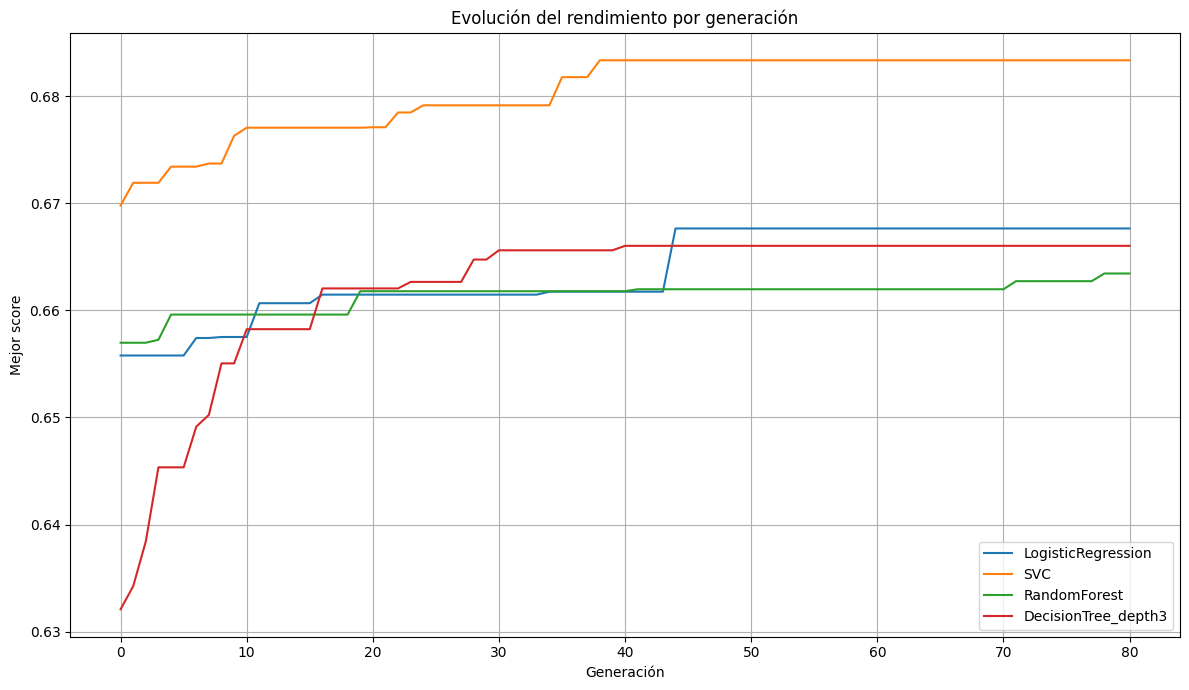

In [36]:
plt.figure(figsize=(12, 7))

for model_name, info in ga_grid_models.items():
    
    evolution = info["evolution"]
    score_name = info["score_name"]
    best_score_key = f"best_{score_name}"

    generations = list(evolution[best_score_key].keys())
    scores = list(evolution[best_score_key].values())

    plt.plot(
        generations,
        scores,
        label=model_name
    )

plt.title("Evolución del rendimiento por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
evaluation_results = []

for model_name, info in ga_grid_models.items():
    selected_features_model = info["selected_features"]
    
    final_model = fitness_models[model_name]
    
    evaluation_results.append(
        evaluar_modelo(
            nombre=f"{model_name}_pyWinEA",
            modelo=final_model,
            X_train_eval=X_train[selected_features_model],
            X_test_eval=X_test[selected_features_model],
            y_train=y_train,
            y_test=y_test
        )
    )

df_evaluation_grid = (
    pd.DataFrame(evaluation_results)
    .sort_values(["g_mean", "especificidad"], ascending=False)
)

df_evaluation_grid

,modelo,n_variables,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,roc_auc
0,LogisticRegression_pyWinEA,24,0.651042,0.636528,0.652492,0.669202,0.635783,0.652278,0.686537
1,SVC_pyWinEA,26,0.626736,0.615385,0.628913,0.653992,0.603834,0.628413,0.685121
2,RandomForest_pyWinEA,40,0.605903,0.588022,0.606707,0.615970,0.597444,0.606636,0.668886
3,DecisionTree_depth3_pyWinEA,12,0.555556,0.628986,0.577084,0.825095,0.329073,0.521073,0.588248


### Comparativa del uso de Grid

In [41]:
BASE_DIR = Path("output_ga")

comparativas = []

# No Grid
# ruta_no_grid = BASE_DIR / "accuracy_models" / "no_grid" / "df_ga_results.csv"
# Para f1:
ruta_no_grid = BASE_DIR / "f1_models" / "no_grid" / "ga_results.csv"
if ruta_no_grid.exists():

    df = pd.read_csv(ruta_no_grid)

    df["estrategia"] = "GA_sin_Grid"

    comparativas.append(df)

# Grid antes de GA
# ruta_grid_before = BASE_DIR / "accuracy_models" / "grid_before" / "df_ga_grid_results.csv"
# Para f1:
ruta_grid_before = BASE_DIR / "f1_models" / "grid_before" / "ga_results.csv"
if ruta_grid_before.exists():

    df = pd.read_csv(ruta_grid_before)

    df["estrategia"] = "GA_con_Grid_Previo"

    comparativas.append(df)

# Unificación
df_comparacion = pd.concat(
    comparativas,
    ignore_index=True
)

df_comparacion = df_comparacion[
    [
        "estrategia",
        "fitness_model",
        "n_variables_originales",
        "n_variables_seleccionadas",
        "best_performance"
    ]
]

df_comparacion = df_comparacion.sort_values(
    ["fitness_model", "best_performance"],
    ascending=[True, False]
)

df_comparacion

,estrategia,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
3,GA_sin_Grid,DecisionTree_depth3,69,16,{'f1': 0.6660370782776374}
7,GA_con_Grid_Previo,DecisionTree_depth3,69,12,{'f1': 0.6660370782776374}
4,GA_con_Grid_Previo,LogisticRegression,69,24,{'f1': 0.6676584613617874}
0,GA_sin_Grid,LogisticRegression,69,31,{'f1': 0.6661082593487384}
2,GA_sin_Grid,RandomForest,69,52,{'f1': 0.6641454119288421}
6,GA_con_Grid_Previo,RandomForest,69,40,{'f1': 0.6634513993888994}
5,GA_con_Grid_Previo,SVC,69,26,{'f1': 0.6833698308697276}
1,GA_sin_Grid,SVC,69,50,{'f1': 0.6739459589201466}


In [43]:

df_comparacion["best_performance"] = (
    df_comparacion["best_performance"]
    .apply(lambda x: ast.literal_eval(x)["f1"] if isinstance(x, str) else x["f1"]) # Para cambiar: "accuracy" 
)

tabla_resumen = df_comparacion.pivot_table(
    index="fitness_model",
    columns="estrategia",
    values=["best_performance", "n_variables_seleccionadas"]
)

tabla_resumen

best_performance             n_variables_seleccionadas  \
estrategia          GA_con_Grid_Previo GA_sin_Grid        GA_con_Grid_Previo   
fitness_model                                                                  
DecisionTree_depth3           0.666037    0.666037                      12.0   
LogisticRegression            0.667658    0.666108                      24.0   
RandomForest                  0.663451    0.664145                      40.0   
SVC                           0.683370    0.673946                      26.0   

                                 
estrategia          GA_sin_Grid  
fitness_model                    
DecisionTree_depth3        16.0  
LogisticRegression         31.0  
RandomForest               52.0  
SVC                        50.0

### Guardado

In [39]:
# Guardado de resultados 
# OUTPUT_DIR = Path("output_ga", "accuracy_models" , "grid_before")  
# Cambiar a F1: 
OUTPUT_DIR = Path("output_ga", "f1_models" , "grid_before")  
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(ga_grid_models, OUTPUT_DIR / "ga_models.pkl")

df_ga_grid_results.to_csv(
    OUTPUT_DIR / "ga_results.csv",
    index=False
)

df_evaluation_grid.to_csv(
    OUTPUT_DIR / "evaluation_models.csv",
    index=False
)

df_optimal_generations_grid.to_csv(
    OUTPUT_DIR / "optimal_generations_by_fitness.csv",
    index=False
)

for model_name, info in ga_grid_models.items():
    pd.Series(
        info["selected_features"],
        name="variable"
    ).to_csv(
        OUTPUT_DIR / f"variables_seleccionadas_{model_name}.csv",
        index=False
    )

print("Resultados guardados correctamente.")

Resultados guardados correctamente.


## 5. Tests 

### 5.1 Carga y visualización de resultados


In [45]:
before_grid_models = joblib.load(
    Path(
        "output_ga",
        "f1_models", # Cambiar: accuracy_models
        "grid_before",
        "no_ga",
        "before_grid_models.pkl"
    )
)

ga_bgrid_models = joblib.load(
    Path(
        "output_ga",
        "f1_models",  # Cambiar: accuracy_models
        "grid_before",
        "ga_models.pkl"
    )
)

ga_nogrid_models = joblib.load(
    Path(
        "output_ga",
        "f1_models",  # Cambiar: accuracy_models
        "no_grid",
        "ga_models.pkl"
    )
)

print("Modelos con Grid previo:", list(ga_bgrid_models.keys()))
print("Modelos sin Grid previo:", list(ga_nogrid_models.keys()))
print("Modelos before_grid:", list(before_grid_models.keys()))

Modelos con Grid previo: ['LogisticRegression', 'SVC', 'RandomForest', 'DecisionTree_depth3']
Modelos sin Grid previo: ['LogisticRegression', 'SVC', 'RandomForest', 'DecisionTree_depth3']
Modelos before_grid: ['LogisticRegression', 'SVC', 'RandomForest', 'DecisionTree_depth3']


In [ ]:
def evaluar_ga(model_name, fitness_model, selected_features):
    
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]
    
    modelo = clone(fitness_model)
    
    modelo.fit(
        X_train_sel,
        y_train.values.ravel()
    )
    
    y_pred = modelo.predict(X_test_sel)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()
    
    return {
        "modelo": model_name,
        "n_variables": len(selected_features),
        "accuracy_test": accuracy_score(y_test, y_pred),
        "f1_test": f1_score(y_test, y_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [47]:
accuracy_test_results = []

for model_name, info in ga_bgrid_models.items():
    
    print(f"Evaluando modelo: {model_name}")
    
    selected_features = info["selected_features"]
    
    if "grid_previo_models" in globals() and model_name in ga_bgrid_models:
        fitness_model = ga_bgrid_models[model_name]
    else:
        fitness_model = fitness_models[model_name]
    
    accuracy_test_results.append(
        evaluar_ga(
            model_name=model_name,
            fitness_model=fitness_model,
            selected_features=selected_features
        )
    )

df_test_ga = pd.DataFrame(accuracy_test_results)

df_test_ga = df_test_ga.sort_values(
    "accuracy_test",
    ascending=False
)

df_test_ga

Evaluando modelo: LogisticRegression
Evaluando modelo: SVC
Evaluando modelo: RandomForest
Evaluando modelo: DecisionTree_depth3


,modelo,n_variables,accuracy_test,f1_test,TN,FP,FN,TP
0,LogisticRegression,24,0.651042,0.636528,199,114,87,176
1,SVC,26,0.626736,0.615385,189,124,91,172
2,RandomForest,40,0.605903,0.588022,187,126,101,162
3,DecisionTree_depth3,12,0.555556,0.628986,103,210,46,217


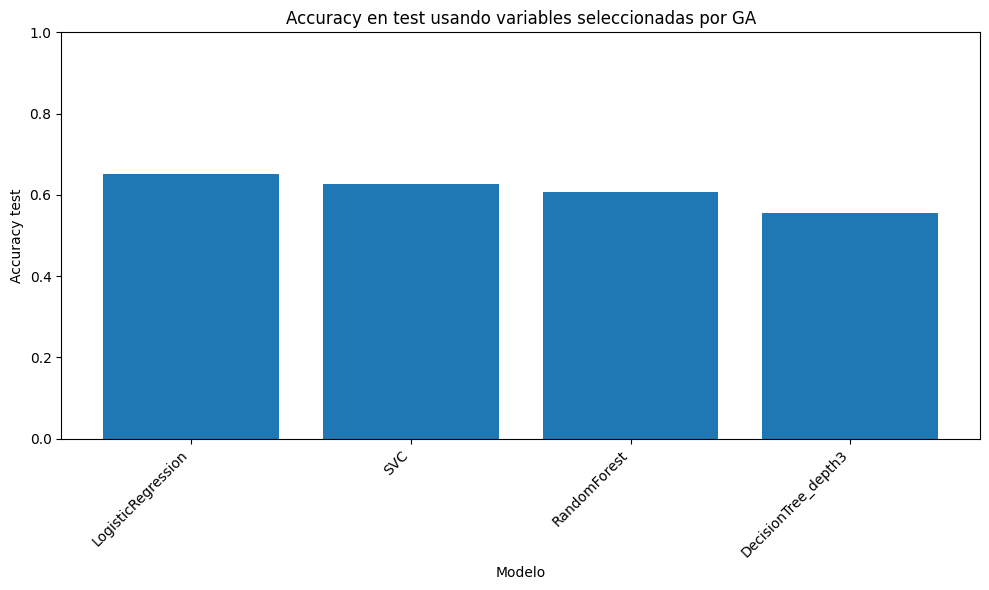

In [48]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_test_ga["modelo"],
    df_test_ga["accuracy_test"]
)

plt.title("Accuracy en test usando variables seleccionadas por GA")
plt.xlabel("Modelo")
plt.ylabel("Accuracy test")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

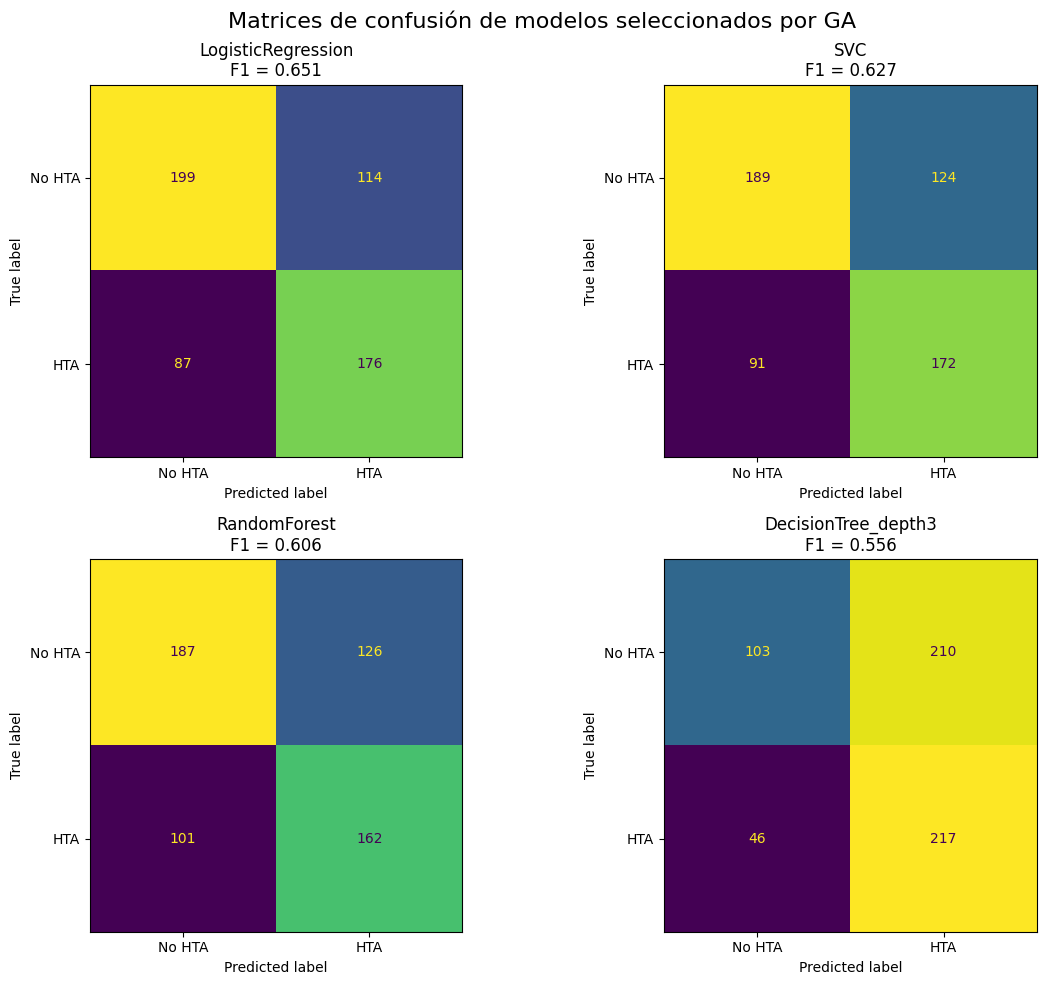

In [ ]:
n_models = len(ga_bgrid_models)

n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for idx, (model_name, info) in enumerate(ga_bgrid_models.items()):

    selected_features = info["selected_features"]

    if "grid_previo_models" in globals() and model_name in ga_bgrid_models:
        fitness_model = ga_bgrid_models[model_name]
    else:
        fitness_model = fitness_models[model_name]

    modelo = clone(fitness_model)

    modelo.fit(
        X_train[selected_features],
        y_train.values.ravel()
    )

    y_pred = modelo.predict(
        X_test[selected_features]
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No HTA", "HTA"]
    )

    disp.plot(
        ax=axes[idx],
        colorbar=False
    )

    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()

    axes[idx].set_title(
        f"{model_name}\nF1 = {accuracy:.3f}" # Para cambiar: Accuracy
    )

for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(
    "Matrices de confusión de modelos seleccionados por GA",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 5.1.1 Comparativa entre GridSearch models y Original models

In [51]:
comparison_results = []

for model_name in ga_nogrid_models.keys():
    
    selected_features = ga_nogrid_models[model_name]["selected_features"]
    fitness_model = fitness_models[model_name]
    
    result = evaluar_ga(
        model_name=model_name,
        fitness_model=fitness_model,
        selected_features=selected_features
    )
    
    result["estrategia"] = "Sin Grid previo"
    comparison_results.append(result)


for model_name in ga_bgrid_models.keys():
    
    selected_features = ga_bgrid_models[model_name]["selected_features"]
    fitness_model = before_grid_models[model_name]
    
    result = evaluar_ga(
        model_name=model_name,
        fitness_model=fitness_model,
        selected_features=selected_features
    )
    
    result["estrategia"] = "Con Grid previo"
    comparison_results.append(result)


df_comparacion_accuracy = pd.DataFrame(comparison_results)

df_comparacion_accuracy = df_comparacion_accuracy[
    [
        "modelo",
        "estrategia",
        "n_variables",
        "accuracy_test",
        "f1_test",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].sort_values(
    ["modelo", "estrategia"]
)


In [52]:
tabla_accuracy_f1 = df_comparacion_accuracy.pivot(
    index="modelo",
    columns="estrategia",
    values=["accuracy_test", "f1_test", "n_variables"]
)

tabla_accuracy_f1.round(4)

accuracy_test                         f1_test  \
estrategia          Con Grid previo Sin Grid previo Con Grid previo   
modelo                                                                
DecisionTree_depth3          0.5556          0.5556          0.6290   
LogisticRegression           0.6337          0.6632          0.6085   
RandomForest                 0.6146          0.6128          0.5919   
SVC                          0.6215          0.6285          0.6379   

                                        n_variables                  
estrategia          Sin Grid previo Con Grid previo Sin Grid previo  
modelo                                                               
DecisionTree_depth3          0.6290            12.0            16.0  
LogisticRegression           0.6434            24.0            31.0  
RandomForest                 0.5967            40.0            52.0  
SVC                          0.6232            26.0            50.0

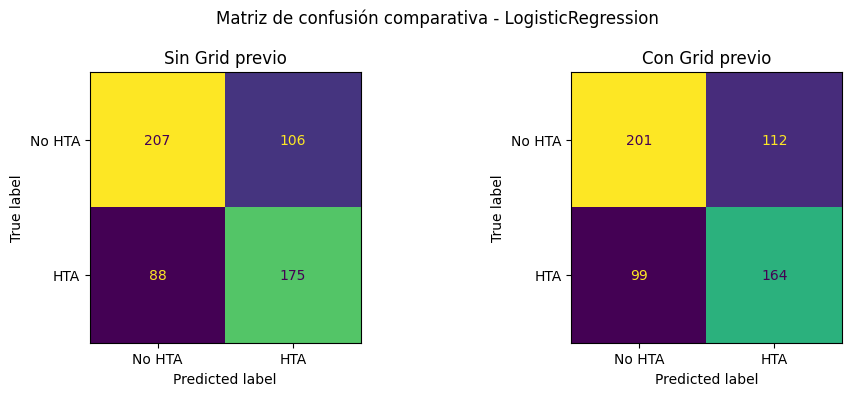

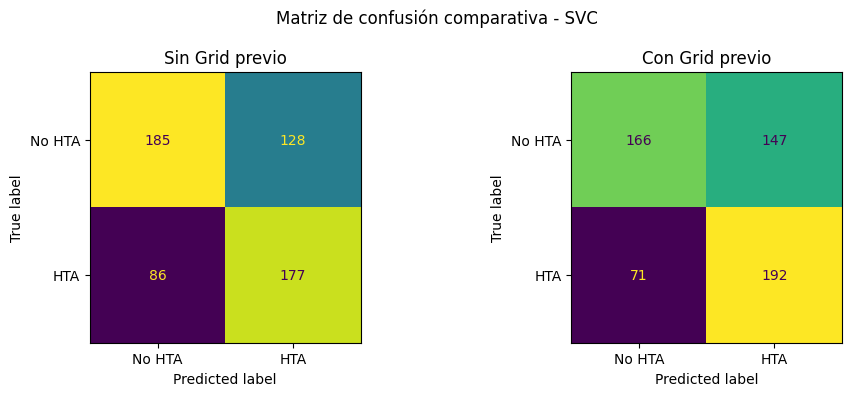

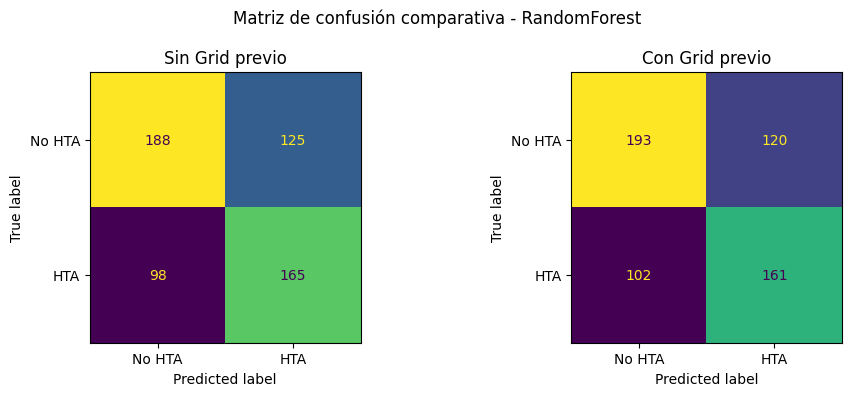

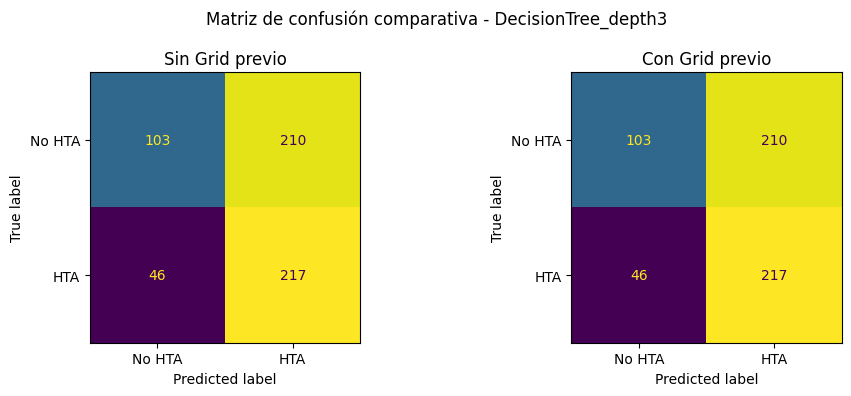

In [ ]:
for model_name in ga_nogrid_models.keys():
    
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4)
    )
    
    # Sin Grid previo
    selected_features_nogrid = ga_nogrid_models[model_name]["selected_features"]
    model_nogrid = clone(fitness_models[model_name])
    
    model_nogrid.fit(
        X_train[selected_features_nogrid],
        y_train.values.ravel()
    )
    
    pred_nogrid = model_nogrid.predict(
        X_test[selected_features_nogrid]
    )
    
    cm_nogrid = confusion_matrix(
        y_test,
        pred_nogrid,
        labels=[0, 1]
    )
    
    disp_nogrid = ConfusionMatrixDisplay(
        confusion_matrix=cm_nogrid,
        display_labels=["No HTA", "HTA"]
    )
    
    disp_nogrid.plot(
        ax=axes[0],
        colorbar=False
    )
    
    axes[0].set_title("Sin Grid previo")
    
    
    # Con Grid previo
    selected_features_bgrid = ga_bgrid_models[model_name]["selected_features"]
    model_bgrid = clone(before_grid_models[model_name])
    
    model_bgrid.fit(
        X_train[selected_features_bgrid],
        y_train.values.ravel()
    )
    
    pred_bgrid = model_bgrid.predict(
        X_test[selected_features_bgrid]
    )
    
    cm_bgrid = confusion_matrix(
        y_test,
        pred_bgrid,
        labels=[0, 1]
    )
    
    disp_bgrid = ConfusionMatrixDisplay(
        confusion_matrix=cm_bgrid,
        display_labels=["No HTA", "HTA"]
    )
    
    disp_bgrid.plot(
        ax=axes[1],
        colorbar=False
    )
    
    axes[1].set_title("Con Grid previo")
    
    fig.suptitle(f"Matriz de confusión comparativa - {model_name}")
    plt.tight_layout()
    plt.show()

### 5.2 Comparación de subconjuntos de variables seleccionados por GA

In [ ]:
comparison_variable_sets = []

variable_sets = {
    model_name: info["selected_features"]
    for model_name, info in ga_bgrid_models.items()
}

evaluation_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

for subset_name, selected_features in variable_sets.items():

    modelo = clone(evaluation_model)

    modelo.fit(
        X_train[selected_features],
        y_train.values.ravel()
    )

    pred = modelo.predict(
        X_test[selected_features]
    )

    comparison_variable_sets.append({
        "subseto_variables": subset_name,
        "n_variables": len(selected_features),
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

df_variable_sets = pd.DataFrame(
    comparison_variable_sets
).sort_values(
    "accuracy",
    ascending=False
)

df_variable_sets

,subseto_variables,n_variables,accuracy,f1
0,LogisticRegression,24,0.651042,0.636528
2,RandomForest,40,0.647569,0.613333
1,SVC,26,0.623264,0.589792
3,DecisionTree_depth3,12,0.593750,0.580645


### 5.3 Optimización de variables seleccionadas por GA

En este apartado se estudia si el mejor subconjunto de variables encontrado por el algoritmo genético puede reducirse todavía más sin perder rendimiento en test.

Para ello:
1. Se toma el subconjunto de variables que obtuvo mejor `accuracy` || `f1`.
2. Se ordenan sus variables según importancia mediante Random Forest.
3. Se evalúan distintos tamaños de subconjunto.
4. Se comprueba si usar menos variables mantiene o mejora el rendimiento.

In [60]:
# GRID_SCORING = "accuracy"
# Para repetirlo con F1:
GRID_SCORING = "f1"

In [ ]:
grid_variable_results = []
grid_variable_models = {}

for model_name in ga_bgrid_models.keys():

    print(f"\nGridSearch sobre variables GA: {model_name}")

    selected_features = ga_bgrid_models[model_name]["selected_features"]

    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]

    base_model = clone(fitness_models[model_name])

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[model_name],
        scoring=GRID_SCORING,
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(
        X_train_sel,
        y_train.values.ravel()
    )

    best_model = grid.best_estimator_

    pred_train = best_model.predict(X_train_sel)
    pred_test = best_model.predict(X_test_sel)

    grid_variable_models[model_name] = {
        "best_model": best_model,
        "selected_features": selected_features,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_
    }

    grid_variable_results.append({
        "modelo": model_name,
        "n_variables": len(selected_features),
        "best_cv_score": grid.best_score_,
        "train_accuracy": accuracy_score(y_train, pred_train),
        "test_accuracy": accuracy_score(y_test, pred_test),
        "train_f1": f1_score(y_train, pred_train),
        "test_f1": f1_score(y_test, pred_test),
        "best_params": str(grid.best_params_)
    })

df_grid_variable_results = pd.DataFrame(grid_variable_results)

df_grid_variable_results = df_grid_variable_results.sort_values(
    "test_f1", # Cambiar: test_accuracy
    ascending=False
)

df_grid_variable_results


GridSearch sobre variables GA: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

GridSearch sobre variables GA: SVC
Fitting 5 folds for each of 9 candidates, totalling 45 fits

GridSearch sobre variables GA: RandomForest
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearch sobre variables GA: DecisionTree_depth3
Fitting 5 folds for each of 36 candidates, totalling 180 fits


,modelo,n_variables,best_cv_score,train_accuracy,test_accuracy,train_f1,test_f1,best_params
0,LogisticRegression,24,0.667658,0.677587,0.633681,0.665120,0.608534,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline..."
1,SVC,26,0.683370,0.688012,0.621528,0.706788,0.637874,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}"
2,RandomForest,40,0.668233,0.792256,0.605903,0.785550,0.583486,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s..."
3,DecisionTree_depth3,12,0.666037,0.631422,0.555556,0.680439,0.628986,"{'criterion': 'gini', 'max_depth': 3, 'min_sam..."


Comparativa antes y después del GridSearch sobre variables GA

In [62]:
df_base_ga = df_variable_sets.rename(
    columns={
        "subseto_variables": "modelo",
        "accuracy": "test_accuracy",
        "f1": "test_f1"
    }
).copy()

df_base_ga["version"] = "GA sin Grid final"

df_grid_ga = df_grid_variable_results[
    ["modelo", "n_variables", "test_accuracy", "test_f1"]
].copy()

df_grid_ga["version"] = "GA + Grid final"

df_comparacion_grid_variables = pd.concat(
    [df_base_ga, df_grid_ga],
    ignore_index=True
)

df_comparacion_grid_variables = df_comparacion_grid_variables[
    ["modelo", "version", "n_variables", "test_accuracy", "test_f1"]
].sort_values(
    ["modelo", "version"]
)

df_comparacion_grid_variables

,modelo,version,n_variables,test_accuracy,test_f1
7,DecisionTree_depth3,GA + Grid final,12,0.555556,0.628986
3,DecisionTree_depth3,GA sin Grid final,12,0.593750,0.580645
4,LogisticRegression,GA + Grid final,24,0.633681,0.608534
0,LogisticRegression,GA sin Grid final,24,0.651042,0.636528
6,RandomForest,GA + Grid final,40,0.605903,0.583486
1,RandomForest,GA sin Grid final,40,0.647569,0.613333
5,SVC,GA + Grid final,26,0.621528,0.637874
2,SVC,GA sin Grid final,26,0.623264,0.589792


---

# Métrica Personalizada

Uso de una métrica personalizada donde el peso recae sobre métricas que hemos creado para comprobar si hay un cambio significativo respecto a las que vienen dadas por sklearn

In [13]:
# Definición de métricas
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def sensitivity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0


def gmean_score(y_true, y_pred):
    sensitivity = sensitivity_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

def custom_metric(y_true, y_pred):
    precision = specificity_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, zero_division=0)
    
    return (0.6 * precision) + (0.4 * recall)

custom_scorer = make_scorer(specificity_score,greater_is_better=True)

In [14]:
# Función Evaluación
def evaluar_modelo(nombre, modelo, X_train_eval, X_test_eval, y_train, y_test):
    modelo.fit(X_train_eval, y_train.values.ravel())
    
    y_pred = modelo.predict(X_test_eval)
    
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test_eval)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    return {
        "modelo": nombre,
        "n_variables": X_train_eval.shape[1],
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "sensibilidad": sensitivity_score(y_test, y_pred),
        "especificidad": specificity_score(y_test, y_pred),
        "g_mean": gmean_score(y_test, y_pred),
        "roc_auc": roc_auc,
        "custom_metric": custom_metric(y_test, y_pred)
    }

In [11]:
# Modelos a usar
custom_models = {
     "LogisticRegression": LogisticRegression(
         max_iter=1000,
         class_weight="balanced",
         solver="liblinear",
         random_state=RANDOM_STATE
     ),
    
     "SVC": SVC(
         kernel="rbf",
         class_weight="balanced",
         probability=True,
         random_state=RANDOM_STATE
     )
}

## 1. Baseline

Modelos originales sin el GA y sin entrenamiento previo.

In [ ]:
baseline_results = []

for model_name, model in custom_models.items():

    resultado = evaluar_modelo(
        nombre=model_name,
        modelo=model,
        X_train_eval=X_train,
        X_test_eval=X_test,
        y_train=y_train,
        y_test=y_test
    )

    baseline_results.append(resultado)

df_baseline = pd.DataFrame(baseline_results)

df_baseline

,modelo,n_variables,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,roc_auc,custom_metric
0,LogisticRegression,111,0.623264,0.598891,0.623043,0.620690,0.625397,0.623039,0.664587,0.623514
1,SVC,111,0.513889,0.517241,0.519102,0.574713,0.463492,0.516115,0.527641,0.507980


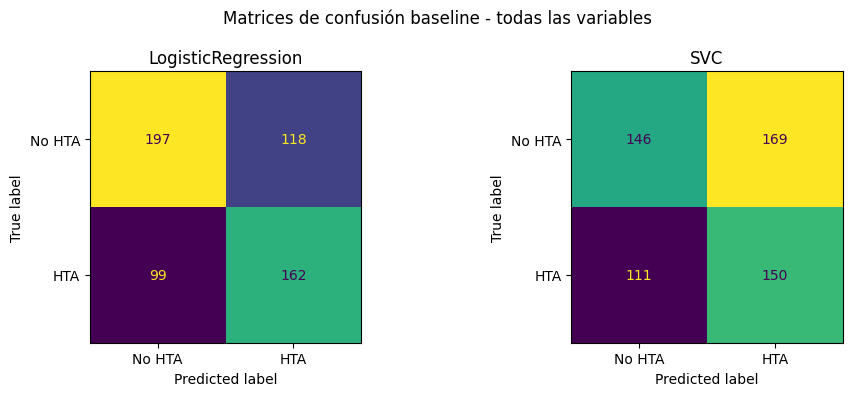

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (model_name, model) in enumerate(custom_models.items()):

    modelo = clone(model)

    modelo.fit(
        X_train,
        y_train.values.ravel()
    )

    y_pred = modelo.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No HTA", "HTA"]
    )

    disp.plot(
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(model_name)

plt.suptitle("Matrices de confusión baseline - todas las variables")
plt.tight_layout()
plt.show()

## 1. Ejecución GA

In [12]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# mediante esta línea se convierte gmean en el measure
scorer = "roc_auc" # make_scorer(gmean_score) "accuracy"

POPULATION_SIZE = 200  # Cambiar a 300 si es en servidores
GENERATIONS = 80
ANNIHILATION = 0.10
ELITISM = 0.15
MUTATION_RATE = 0.05

In [15]:
ga_results = []
ga_models = {}

for model_name, model in custom_models.items():
    print(f"\nEntrenando GA con fitness model: {model_name}")
    
    ga = GA(
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        cv=cv_strategy,
        fitness=model,
        score=scorer,
        annihilation=ANNIHILATION,
        elitism=ELITISM,
        mutation_rate=MUTATION_RATE,
        positive_class=1,
        id=f"GA_MAP_alta_{model_name}"
    )
    
    ga.set_features(X_train.columns.tolist())
    
    ga.fit(
        X_train.values,
        y_train.values.ravel()
    )
    
    selected_features_model = list(ga.best_features)
    evolution, score_name = ga.training_evolution()
    
    ga_models[model_name] = {
        "ga": ga,
        "selected_features": selected_features_model,
        "evolution": evolution,
        "score_name": score_name
    }
    
    ga_results.append({
        "fitness_model": model_name,
        "n_variables_originales": X_train.shape[1],
        "n_variables_seleccionadas": len(selected_features_model),
        "best_performance": ga.best_performance
    })

df_ga_results = pd.DataFrame(ga_results)
df_ga_results



Entrenando GA con fitness model: LogisticRegression


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [18:55<00:00, 14.20s/it]



Entrenando GA con fitness model: SVC


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [5:19:42<00:00, 239.79s/it]  


,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
0,LogisticRegression,69,31,{'roc_auc': 0.7396097295075366}
1,SVC,69,32,{'roc_auc': 0.7437523506823059}


## 2. Evaluar resultados

In [85]:
type(custom_models)

dict

In [38]:
custom_models

{'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                    solver='liblinear'),
 'SVC': SVC(class_weight='balanced', probability=True, random_state=42)}

In [ ]:
resultados_custom = []

for model_name in custom_models.keys():

    selected_features = ga_models[model_name]["selected_features"]
    modelo = custom_models[model_name]

    resultado = evaluar_modelo(
        nombre=model_name,
        modelo=modelo,
        X_train_eval=X_train[selected_features],
        X_test_eval=X_test[selected_features],
        y_train=y_train,
        y_test=y_test
    )

    resultado["n_variables"] = len(selected_features)

    resultados_custom.append(resultado)

df_resultados_custom = pd.DataFrame(resultados_custom)

df_resultados_custom

,modelo,n_variables,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,roc_auc,custom_metric
0,LogisticRegression,31,0.657986,0.634508,0.657363,0.650190,0.664537,0.657324,0.703458,0.658798
1,SVC,32,0.619792,0.613757,0.623131,0.661597,0.584665,0.621942,0.689841,0.615438


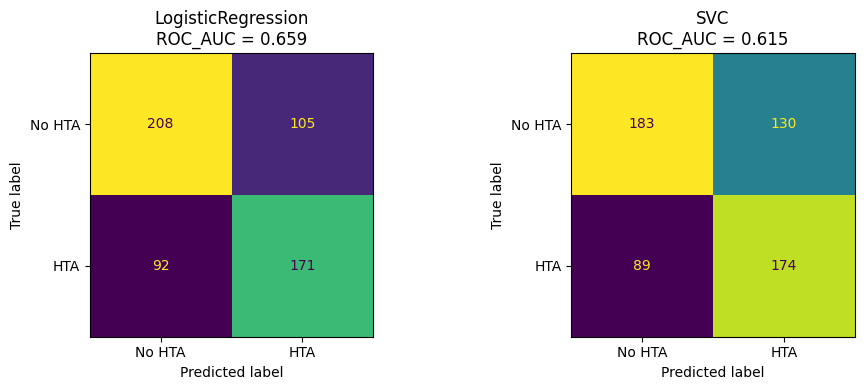

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)

for i, model_name in enumerate(custom_models.keys()):

    selected_features = ga_models[model_name]["selected_features"]

    modelo = clone(custom_models[model_name])

    modelo.fit(
        X_train[selected_features],
        y_train.values.ravel()
    )

    y_pred = modelo.predict(
        X_test[selected_features]
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    score = custom_metric(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No HTA", "HTA"]
    )

    disp.plot(
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(
        f"{model_name}\nROC_AUC = {score:.3f}"
    )

plt.tight_layout()
plt.show()

---

---
# GA Multiobjetivo 

Intento de mejora de resultados aplicanco un Multiobjetivo para forzar al GA a encontrar un equilibrio entre las métricas que se le indiquen

In [10]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

POPULATION_SIZE = 200
GENERATIONS = 80
MUTATION_RATE = 0.10

tournament = TournamentSelection(
    k=2,
    winners=1,
    replacement=False
)

features = X_train.columns.tolist()

## 1. Entrenamiento NSGA-II

In [22]:
nsga_results = {}
nsga_summary = []

for model_name, model in custom_models.items():

    print(f"\nEntrenando NSGA-II con modelo: {model_name}")

    # Obj1:
    # Probar especificidad
    fitness_precision = MonoObjectiveCV(
        estimator=model,
        cv=cv_strategy,
        score=custom_scorer
    )

    # Obj2:
    fitness_recall = MonoObjectiveCV(
        estimator=model,
        cv=cv_strategy,
        score="recall"
    )

    nsga = NSGA2(
        population=Population(size=POPULATION_SIZE),
        generations=GENERATIONS,
        fitness=[fitness_precision, fitness_recall],
        mutation_rate=MUTATION_RATE,
        optimize_features=False,
        selection=tournament,
        id=f"NSGA2_precision_recall_{model_name}",
        random_state=RANDOM_STATE
    )

    nsga.set_features(features)

    nsga.fit(
        X_train.values,
        y_train.values.ravel()
    )

    nsga_results[model_name] = nsga

    nsga_summary.append({
        "modelo": model_name,
        "population_size": POPULATION_SIZE,
        "generations": GENERATIONS,
        "mutation_rate": MUTATION_RATE
    })

df_nsga_summary = pd.DataFrame(nsga_summary)
df_nsga_summary


Entrenando NSGA-II con modelo: LogisticRegression


(NSGAII) Generations (form 0 to 80): 100%|██████████| 80/80 [10:20<00:00,  7.76s/it]



Entrenando NSGA-II con modelo: SVC


(NSGAII) Generations (form 0 to 80): 100%|██████████| 80/80 [6:30:54<00:00, 293.18s/it]  


,modelo,population_size,generations,mutation_rate
0,LogisticRegression,200,80,0.1
1,SVC,200,80,0.1


## 2. Evaluación

### Frente Pareto y Tabla Resultados

In [ ]:
def get_feature_names_from_individual(individual, features):
    return [features[int(i)] for i in individual.features]


def evaluar_pareto_nsga(nsga, model_name):

    pareto_individuals = [
        ind for ind in nsga.population.individuals
        if ind.fitness.rank == 0
    ]

    base_model = nsga.fitness[0].estimator

    rows = []

    for pareto_idx, individual in enumerate(pareto_individuals):

        selected_features = get_feature_names_from_individual(
            individual,
            features
        )

        modelo = clone(base_model)

        modelo.fit(
            X_train[selected_features],
            y_train.values.ravel()
        )

        y_pred = modelo.predict(
            X_test[selected_features]
        )

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            y_pred,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        rows.append({
            "modelo": model_name,
            "pareto_idx": pareto_idx,
            "n_variables": len(selected_features),
            "precision_cv": individual.fitness.values[0],
            "recall_cv": individual.fitness.values[1],
            "accuracy_test": accuracy_score(y_test, y_pred),
            "precision_test": precision,
            "recall_test": recall,
            "f1_test": f1_score(y_test, y_pred),
            "custom_score_test": 0.6 * precision + 0.4 * recall,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "selected_features": selected_features
        })

    return pd.DataFrame(rows)

In [24]:
df_nsga_pareto = pd.concat(
    [
        evaluar_pareto_nsga(nsga, model_name)
        for model_name, nsga in nsga_results.items()
    ],
    ignore_index=True
)

df_nsga_pareto = df_nsga_pareto.sort_values(
    ["custom_score_test", "f1_test"],
    ascending=False
)

df_nsga_pareto[
    [
        "modelo",
        "pareto_idx",
        "n_variables",
        "precision_cv",
        "recall_cv",
        "accuracy_test",
        "precision_test",
        "recall_test",
        "f1_test",
        "custom_score_test",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

,modelo,pareto_idx,n_variables,precision_cv,recall_cv,accuracy_test,precision_test,recall_test,f1_test,custom_score_test,TN,FP,FN,TP
0,LogisticRegression,0,2,0.059836,0.937366,0.472222,0.462385,0.958175,0.623762,0.660701,20,293,11,252
1,LogisticRegression,1,2,0.059836,0.937366,0.472222,0.462385,0.958175,0.623762,0.660701,20,293,11,252
182,LogisticRegression,182,2,0.059836,0.937366,0.472222,0.462385,0.958175,0.623762,0.660701,20,293,11,252
189,LogisticRegression,189,2,0.059836,0.937366,0.472222,0.462385,0.958175,0.623762,0.660701,20,293,11,252
247,SVC,47,22,0.580143,0.771007,0.633681,0.577381,0.737643,0.647746,0.641486,171,142,69,194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,LogisticRegression,59,2,0.942967,0.085720,0.527778,0.390244,0.060837,0.105263,0.258481,288,25,247,16
63,LogisticRegression,63,2,0.942967,0.085720,0.527778,0.390244,0.060837,0.105263,0.258481,288,25,247,16
125,LogisticRegression,125,2,0.941607,0.089012,0.527778,0.390244,0.060837,0.105263,0.258481,288,25,247,16
186,LogisticRegression,186,2,0.942967,0.085720,0.527778,0.390244,0.060837,0.105263,0.258481,288,25,247,16


### Mejor solución por modelo y Matriz de Confusión

In [25]:
df_best_nsga = (
    df_nsga_pareto
    .sort_values(["modelo", "custom_score_test"], ascending=[True, False])
    .groupby("modelo")
    .head(1)
    .reset_index(drop=True)
)

df_best_nsga[
    [
        "modelo",
        "pareto_idx",
        "n_variables",
        "accuracy_test",
        "precision_test",
        "recall_test",
        "f1_test",
        "custom_score_test",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

,modelo,pareto_idx,n_variables,accuracy_test,precision_test,recall_test,f1_test,custom_score_test,TN,FP,FN,TP
0,LogisticRegression,0,2,0.472222,0.462385,0.958175,0.623762,0.660701,20,293,11,252
1,SVC,47,22,0.633681,0.577381,0.737643,0.647746,0.641486,171,142,69,194


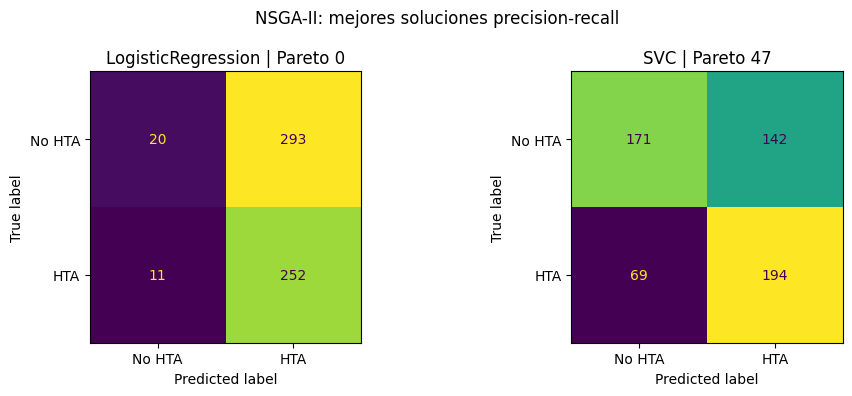

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, row in df_best_nsga.iterrows():

    model_name = row["modelo"]
    pareto_idx = row["pareto_idx"]
    selected_features = row["selected_features"]

    base_model = nsga_results[model_name].fitness[0].estimator
    modelo = clone(base_model)

    modelo.fit(
        X_train[selected_features],
        y_train.values.ravel()
    )

    y_pred = modelo.predict(
        X_test[selected_features]
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No HTA", "HTA"]
    )

    disp.plot(
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(
        f"{model_name} | Pareto {pareto_idx}"
    )

plt.suptitle("NSGA-II: mejores soluciones precision-recall")
plt.tight_layout()
plt.show()

## 3. Guardado

In [27]:
OUTPUT_DIR = Path("output_ga", "multiobjective_precision_recall", "specifity&recall")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Guardar todos los modelos juntos
joblib.dump(
    nsga_results,
    OUTPUT_DIR / "nsga2_models.pkl"
)

# Guardar cada modelo por separado con joblib
for model_name, nsga in nsga_results.items():

    model_id = nsga.id

    joblib.dump(
        nsga,
        OUTPUT_DIR / f"{model_id}.pkl"
    )

    print(f"Modelo guardado: {model_id}.pkl")

# Guardar tablas
df_nsga_pareto.to_csv(
    OUTPUT_DIR / "nsga2_pareto_results.csv",
    index=False
)

df_best_nsga.to_csv(
    OUTPUT_DIR / "nsga2_best_solutions.csv",
    index=False
)

print("Resultados NSGA-II guardados en:", OUTPUT_DIR.resolve())

Modelo guardado: NSGA2_precision_recall_LogisticRegression.pkl
Modelo guardado: NSGA2_precision_recall_SVC.pkl
Resultados NSGA-II guardados en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_ga\multiobjective_precision_recall\specifity&recall
